# Proyecto Prediccion Precios Autos Usados

## Información del caso

### TEMA DEL CASO

Predicción de Precios de Vehículos Usados

### **ANTECEDENTES**

Este caso utiliza un dataset masivo que contiene casi 500,000 anuncios de vehículos de segunda mano de Craigslist en Estados Unidos. El dataset es extremadamente rico, con características detalladas para cada vehículo, incluyendo marca, modelo, año, kilometraje (odómetro), tipo de combustible, transmisión y condición. El mercado de autos usados es complejo y los precios varían enormemente. El reto es construir un modelo que pueda predecir el precio de un auto usado con alta precisión basándose en sus características.	


### **OBJETIVO**

Construir un sistema de analítica completo que:

1. Implemente un pipeline de limpieza de datos robusto.
2. Realice un análisis exploratorio de datos (EDA) para identificar las plataformas y géneros dominantes.
3. Entrene un modelo de Machine Learning (Regresión) capaz de predecir las Ventas_Totales de futuros videojuegos.
4. Despliegue el modelo y los insights en un sistema desacoplado de API y Dashboard.

### **ACTIVIDADES**

## Análsis de datos

### Librerías

In [1]:
# pandas para manejar df (tablas)
import pandas as pd
# missingno para visualizar datos faltantes en df
import missingno as msno
# numpy para manejar datos específicos con pandas (procesamiento computacional más rápido)
import numpy as np

### Cargar datos

In [ ]:
# cargar datps
df_autos = pd.read_csv(r"C:\Users\JaviF\Desktop\Project_Fabian\Autos_Usados\data\raw\vehicles.csv")

### Análisis inicial de los datos

In [3]:
# Mostrar TODAS las columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
df_autos.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [4]:
print(f"\n📊 DATOS CARGADOS")
print(f"   Filas: { len(df_autos):,}")
print(f"   Columnas: {len(df_autos.columns)}")
#print(f"   Tamaño en memoria: {df_autos.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


📊 DATOS CARGADOS
   Filas: 426,880
   Columnas: 26


In [5]:
# resumen general del df
df_autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [6]:
# nombres de columnas 
df_autos.columns

Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='object')

### Análisis de valores ausentes y valores únicos

In [7]:
# total valores únicos por columnas
print(df_autos.nunique())
print()
# total datos en df
print(len(df_autos))

id              426880
url             426880
region             404
region_url         413
price            15655
year               114
manufacturer        42
model            29667
condition            6
cylinders            8
fuel                 5
odometer        104870
title_status         6
transmission         3
VIN             118264
drive                3
size                 4
type                13
paint_color         12
image_url       241899
description     360911
county               0
state               51
lat              53181
long             53772
posting_date    381536
dtype: int64

426880


In [8]:
# guardar valores únicos en variable
valores_unicos = df_autos.nunique()
valores_unicos

id              426880
url             426880
region             404
region_url         413
price            15655
year               114
manufacturer        42
model            29667
condition            6
cylinders            8
fuel                 5
odometer        104870
title_status         6
transmission         3
VIN             118264
drive                3
size                 4
type                13
paint_color         12
image_url       241899
description     360911
county               0
state               51
lat              53181
long             53772
posting_date    381536
dtype: int64

In [9]:
# total valores asuentes por columna
df_autos.isnull().sum()

id                   0
url                  0
region               0
region_url           0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
image_url           68
description         70
county          426880
state                0
lat               6549
long              6549
posting_date        68
dtype: int64

In [10]:
# guardar en variable
valores_ausentes = df_autos.isnull().sum()

In [11]:
# seleccionar una columna y ver el tipo de dato
type(df_autos["size"])

pandas.core.series.Series

In [12]:
# crear un nuevo df a partir de dos tipos .Series
datos_generales = pd.DataFrame({
    "Valores únicos": valores_unicos, 
    "Nulos": valores_ausentes
})

datos_generales

,Valores únicos,Nulos
id,426880,0
url,426880,0
region,404,0
region_url,413,0
price,15655,0
year,114,1205
manufacturer,42,17646
model,29667,5277
condition,6,174104
cylinders,8,177678


In [13]:
len(df_autos)

426880

In [14]:
# porcentaje de valores ausentes de todas las columnas
round(df_autos.isnull().mean()*100, 3)

id                0.000
url               0.000
region            0.000
region_url        0.000
price             0.000
year              0.282
manufacturer      4.134
model             1.236
condition        40.785
cylinders        41.622
fuel              0.706
odometer          1.031
title_status      1.931
transmission      0.599
VIN              37.725
drive            30.586
size             71.767
type             21.753
paint_color      30.501
image_url         0.016
description       0.016
county          100.000
state             0.000
lat               1.534
long              1.534
posting_date      0.016
dtype: float64

### Análisis de valores ausentes con `missingno`

<Axes: >

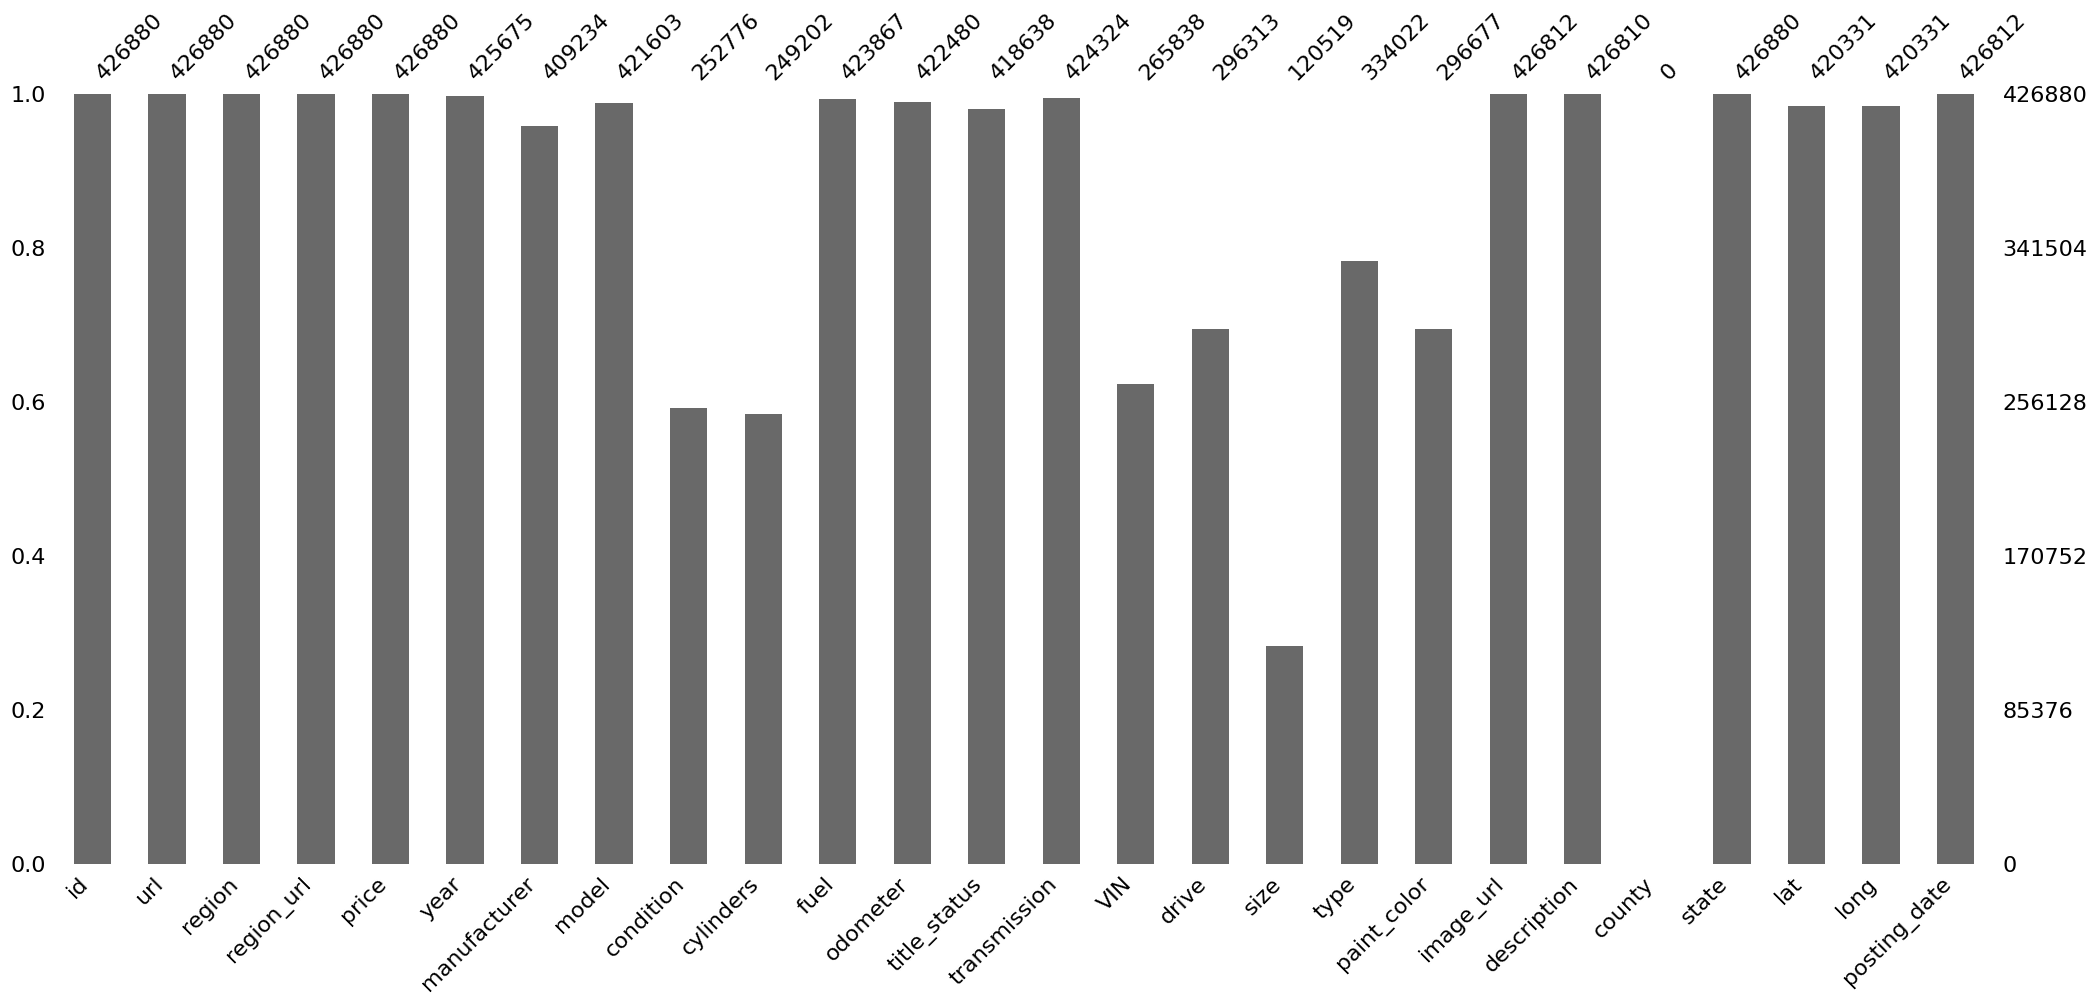

In [15]:
msno.bar(df_autos)

Matriz de valores ausentes (para ver dónde están los valores ausentes, en qué posición)

<Axes: >

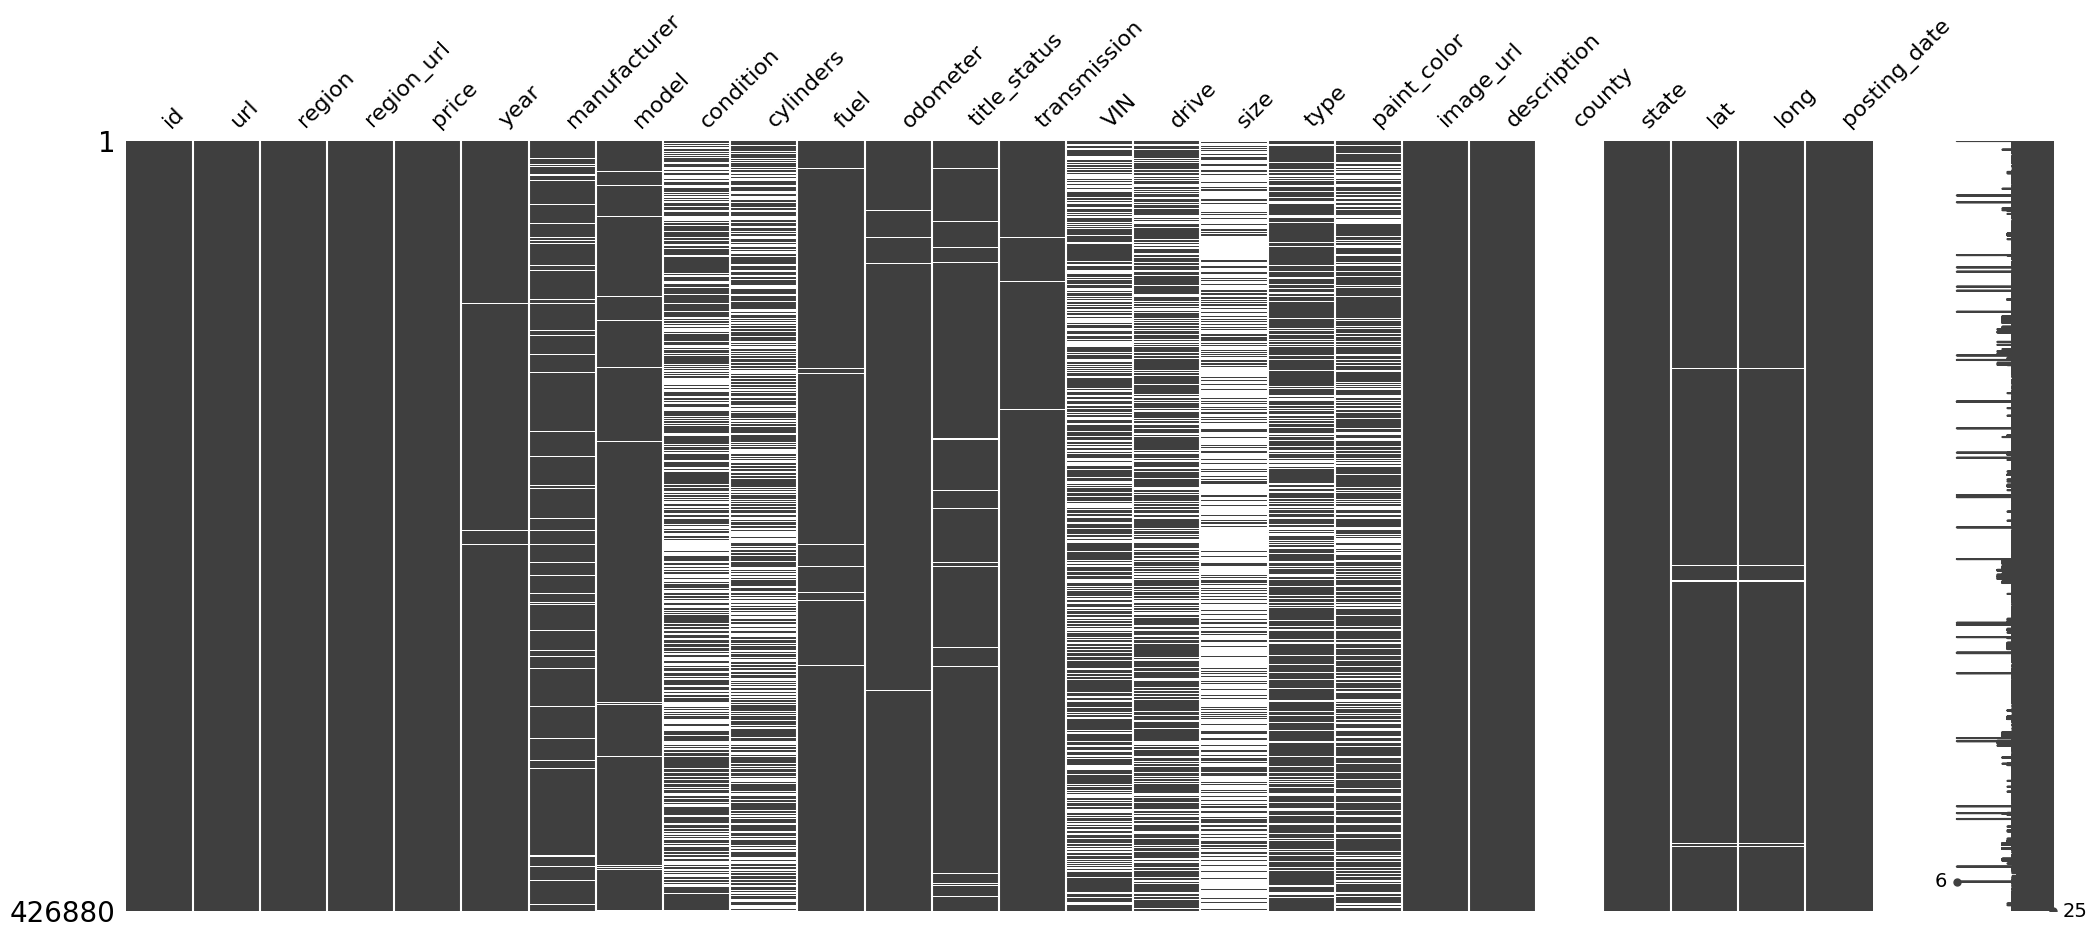

In [16]:
msno.matrix(df_autos)

<Axes: >

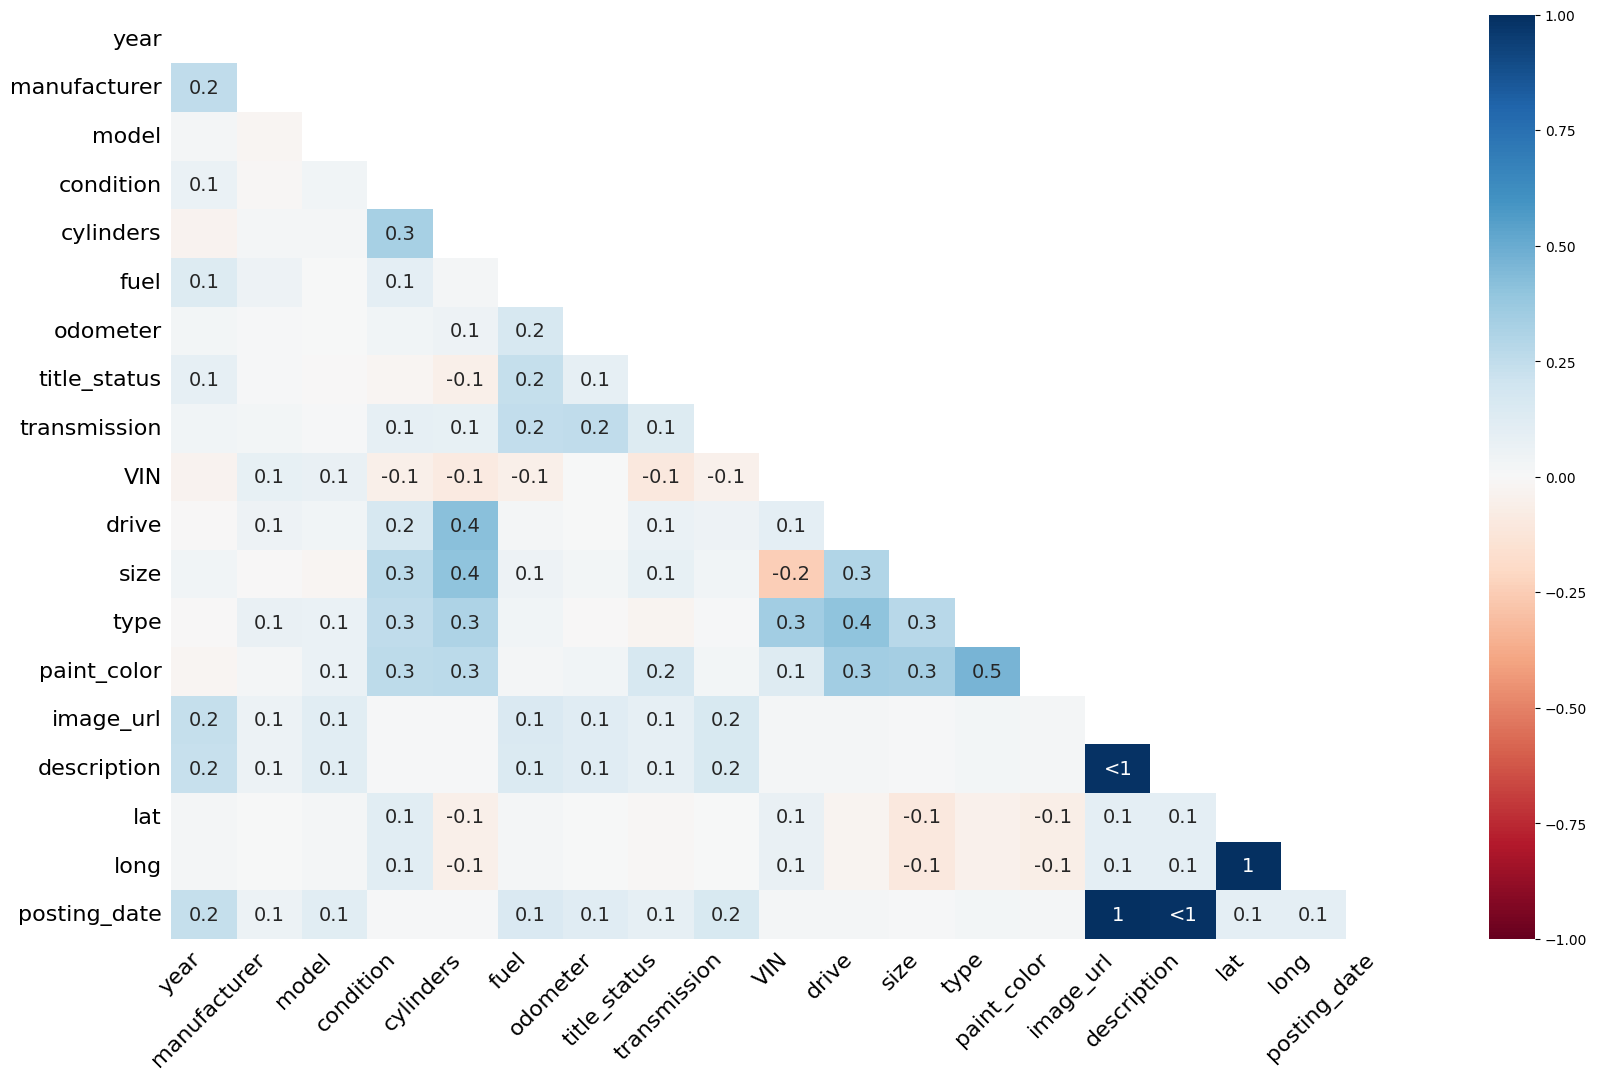

In [17]:
#Un heatmap de correlación entre valores faltantes 
# (si falta el dato en una columna, se ve qué tan fuerte es la correlación (o no) 
# para ver si falta en otra columnas)
msno.heatmap(df_autos)

In [18]:
# 2. Calcular la matriz y redondear los valores a 2 decimales para una mejor lectura en consola
matriz_correlacion_nulos = df_autos.isnull().corr().round(2)

# 3. Imprimir el resultado completo
print("### 🤝 Matriz de Correlación de Nulidad (Valores Faltantes) ###")
# Usamos to_string() para asegurar que la tabla no se trunque si es muy grande
print(matriz_correlacion_nulos.to_string())

### 🤝 Matriz de Correlación de Nulidad (Valores Faltantes) ###
              id  url  region  region_url  price  year  manufacturer  model  condition  cylinders  fuel  odometer  title_status  transmission   VIN  drive  size  type  paint_color  image_url  description  county  state   lat  long  posting_date
id           NaN  NaN     NaN         NaN    NaN   NaN           NaN    NaN        NaN        NaN   NaN       NaN           NaN           NaN   NaN    NaN   NaN   NaN          NaN        NaN          NaN     NaN    NaN   NaN   NaN           NaN
url          NaN  NaN     NaN         NaN    NaN   NaN           NaN    NaN        NaN        NaN   NaN       NaN           NaN           NaN   NaN    NaN   NaN   NaN          NaN        NaN          NaN     NaN    NaN   NaN   NaN           NaN
region       NaN  NaN     NaN         NaN    NaN   NaN           NaN    NaN        NaN        NaN   NaN       NaN           NaN           NaN   NaN    NaN   NaN   NaN          NaN        NaN          Na

### Analizar de forma rápida los datos por columnas

In [19]:
valores_unicos

id              426880
url             426880
region             404
region_url         413
price            15655
year               114
manufacturer        42
model            29667
condition            6
cylinders            8
fuel                 5
odometer        104870
title_status         6
transmission         3
VIN             118264
drive                3
size                 4
type                13
paint_color         12
image_url       241899
description     360911
county               0
state               51
lat              53181
long             53772
posting_date    381536
dtype: int64

In [20]:
columnas_categoricas = [
    "condition","title_status", "drive", "fuel", "transmission",
    "cylinders", "size", "type", "paint_color" , "manufacturer"
]

resumen_dict = {}

for col in columnas_categoricas:
    tabla = pd.DataFrame({
        'Frecuencia': df_autos[col].value_counts(dropna=False),
        'Porcentaje (%)': df_autos[col].value_counts(normalize=True, dropna=False) * 100
    })
    resumen_dict[col] = tabla
    print(f"\n{'='*60}")
    print(f"📊 Distribución de la columna: {col}")
    print(tabla)




📊 Distribución de la columna: condition
           Frecuencia  Porcentaje (%)
condition                            
NaN            174104       40.785232
good           121456       28.452024
excellent      101467       23.769443
like new        21178        4.961113
fair             6769        1.585692
new              1305        0.305707
salvage           601        0.140789

📊 Distribución de la columna: title_status
              Frecuencia  Porcentaje (%)
title_status                            
clean             405117       94.901846
NaN                 8242        1.930753
rebuilt             7219        1.691108
salvage             3868        0.906109
lien                1422        0.333115
missing              814        0.190686
parts only           198        0.046383

📊 Distribución de la columna: drive
       Frecuencia  Porcentaje (%)
drive                            
4wd        131904       30.899550
NaN        130567       30.586347
fwd        105517       24.7181

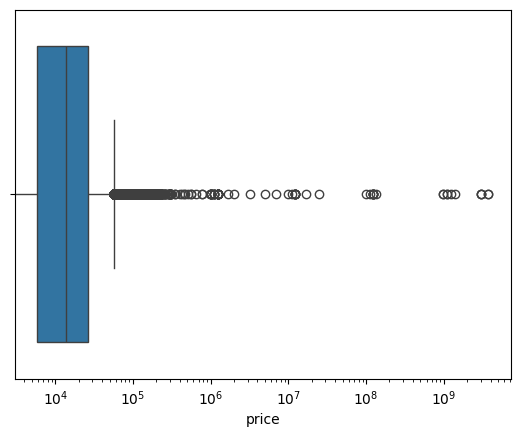

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df_autos['price'])
plt.xscale('log')

Text(0.5, 1.0, 'Revisión de coherencia año vs kilometraje')

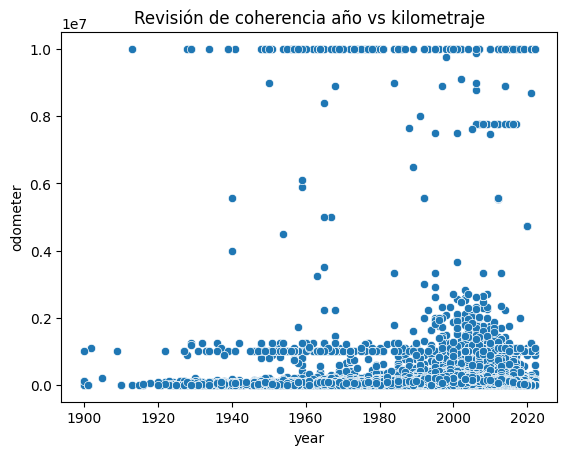

In [22]:
sns.scatterplot(data=df_autos, x='year', y='odometer')
plt.title("Revisión de coherencia año vs kilometraje")


## Limpieza de datos

### CREAR COPIA DE SEGURIDAD

In [23]:
df_limpio = df_autos.copy()
print(len(df_limpio))
print()
df_limpio.columns

426880



Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='object')

### ELIMINACIÓN DE COLUMNAS INNECESARIAS

In [24]:
columnas_a_eliminar = [
    'county',           # 100% nulos
    'id',               # Solo identificador único
    'url', 
    'region',                          # URL no predictiva
    'region_url',       # Redundante con 'state'
    'image_url',        # No usaremos imágenes (por ahora)
    'VIN',              # 37.7% nulos, difícil de procesar
    'lat',              # 1.5% nulos, usar 'state' es suficiente
    'long',             # 1.5% nulos
    'posting_date',     # No relevante para precio
    'description',       # Texto libre (análisis futuro)
    'size'       ,       # 72 % de valores nulos mejor eliminarla
    'paint_color',       # 45% de valores nulos, eliminar
    'title_status',     #Varianza nula 94% datos de clean
]



In [25]:
# Filtrar solo columnas que existen en el dataset
columnas_existentes = [col for col in columnas_a_eliminar if col in df_limpio.columns]

print(f"\nColumnas a eliminar: {len(columnas_existentes)}")
for col in columnas_existentes:
    print(f"   - {col}")

df_limpio = df_limpio.drop(columns=columnas_existentes)

print(f"\nDespués: {len(df_limpio.columns)} columnas")
print(f"Columnas restantes: {list(df_limpio.columns)}")


Columnas a eliminar: 14
   - county
   - id
   - url
   - region
   - region_url
   - image_url
   - VIN
   - lat
   - long
   - posting_date
   - description
   - size
   - paint_color
   - title_status

Después: 12 columnas
Columnas restantes: ['price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'transmission', 'drive', 'type', 'state']


### ESTANDARIZACIÓN DE TIPOS Y NORMALIZACIÓN DE STRINGS

In [26]:
print("\n📊 TIPOS DE DATOS ANTES:")
print(df_limpio.dtypes)

# Convertir YEAR a INT (es año, debe ser entero)
print("  → Convertiendo YEAR a int...")
df_limpio['year'] = pd.to_numeric(df_limpio['year'], errors='coerce').astype('Int64')
# Nota: Int64 (mayúscula) maneja NaN mejor que int64 (minúscula)

# Convertir PRICE a FLOAT (puede haber decimales en teoría)
print("  → Convertiendo PRICE a float...")
df_limpio['price'] = pd.to_numeric(df_limpio['price'], errors='coerce').astype('float64')

# Convertir ODOMETER a FLOAT (puede haber decimales)
print("  → Convertiendo ODOMETER a float...")
df_limpio['odometer'] = pd.to_numeric(df_limpio['odometer'], errors='coerce').astype('float64')



📊 TIPOS DE DATOS ANTES:
price             int64
year            float64
manufacturer     object
model            object
condition        object
cylinders        object
fuel             object
odometer        float64
transmission     object
drive            object
type             object
state            object
dtype: object
  → Convertiendo YEAR a int...
  → Convertiendo PRICE a float...
  → Convertiendo ODOMETER a float...


### Se transforma los cilindros a numero

In [27]:
# Extraer solo el número dentro de la cadena
df_limpio['cylinders'] = (
    df_limpio['cylinders']
    .astype(str)
    .str.extract(r'(\d+)')     # extrae el número si existe
)

# Convertir a tipo numérico (Int64 permite NaN)
df_limpio['cylinders'] = pd.to_numeric(df_limpio['cylinders'], errors='coerce').astype('Int64')

# Mostrar valores únicos finales
print(df_limpio['cylinders'].unique())
print(df_limpio['cylinders'].dtype)

<IntegerArray>
[<NA>, 8, 6, 4, 5, 3, 10, 12]
Length: 8, dtype: Int64
Int64


### DRIVE: Convertir "4wd", "fwd", "rwd" → 0, 1, 2


In [28]:
drive_mapping = {'4wd': 4, 'fwd': 1, 'rwd': 2}
df_limpio['drive'] = df_limpio['drive'].map(drive_mapping)
df_limpio['drive'] = pd.to_numeric(df_limpio['drive'], errors='coerce').astype('Int64')
print(f"   ✓ Mapeo: {drive_mapping}")
print(f"   ✓ Valores únicos: {sorted(df_limpio['drive'].dropna().unique())}")
print(f"   ✓ Tipo: {df_limpio['drive'].dtype}")

   ✓ Mapeo: {'4wd': 4, 'fwd': 1, 'rwd': 2}
   ✓ Valores únicos: [np.int64(1), np.int64(2), np.int64(4)]
   ✓ Tipo: Int64


### Normalizar strings (lowercase + strip) Reemplazar 'nan' (string) con NaN (real) ojito

In [29]:
columnas_string = [
    'manufacturer', 'model', 'condition', 'fuel', 
    'transmission', 'type', 
    'state'
]

for col in columnas_string:
    if col in df_limpio.columns:
        print(f"  → Normalizando {col}...")
        # Convertir a string primero, luego aplicar lower() y strip()
        df_limpio[col] = df_limpio[col].astype(str).str.lower().str.strip()
        # Reemplazar 'nan' (string) con NaN (real) ojito
        df_limpio[col] = df_limpio[col].replace('nan', np.nan)



  → Normalizando manufacturer...
  → Normalizando model...
  → Normalizando condition...
  → Normalizando fuel...
  → Normalizando transmission...
  → Normalizando type...
  → Normalizando state...


### RESULTADOS despues de la normalizacion

In [30]:
print("📊 TIPOS DE DATOS DESPUÉS:")
print("="*70)
print(df_limpio.dtypes)

print("\n" + "="*70)
print("📊 RESUMEN FINAL")
print("="*70)
print(f"Filas: {len(df_limpio):,}")
print(f"Columnas: {len(df_limpio.columns)}")
print(f"Total de nulos: {df_limpio.isnull().sum().sum():,}")

📊 TIPOS DE DATOS DESPUÉS:
price           float64
year              Int64
manufacturer     object
model            object
condition        object
cylinders         Int64
fuel             object
odometer        float64
transmission     object
drive             Int64
type             object
state            object
dtype: object

📊 RESUMEN FINAL
Filas: 426,880
Columnas: 12
Total de nulos: 610,602


In [31]:
print("\n✅ VERIF FINAL:")
print(df_limpio[['year', 'price', 'odometer', 'manufacturer', 'condition']].head(10))
print("\nTipos:")
print(df_limpio[['year', 'price', 'manufacturer', 'condition']].dtypes)


resumen_dict = {}

for col in columnas_string:
    tabla = pd.DataFrame({
        'Frecuencia': df_limpio[col].value_counts(dropna=False),
        'Porcentaje (%)': df_limpio[col].value_counts(normalize=True, dropna=False) * 100
    })
    resumen_dict[col] = tabla
    print(f"\n{'='*60}")
    print(f"📊 Distribución de la columna: {col}")
    print(tabla)


✅ VERIF FINAL:
   year    price  odometer manufacturer condition
0  <NA>   6000.0       NaN          NaN       NaN
1  <NA>  11900.0       NaN          NaN       NaN
2  <NA>  21000.0       NaN          NaN       NaN
3  <NA>   1500.0       NaN          NaN       NaN
4  <NA>   4900.0       NaN          NaN       NaN
5  <NA>   1600.0       NaN          NaN       NaN
6  <NA>   1000.0       NaN          NaN       NaN
7  <NA>  15995.0       NaN          NaN       NaN
8  <NA>   5000.0       NaN          NaN       NaN
9  <NA>   3000.0       NaN          NaN       NaN

Tipos:
year              Int64
price           float64
manufacturer     object
condition        object
dtype: object

📊 Distribución de la columna: manufacturer
                 Frecuencia  Porcentaje (%)
manufacturer                               
ford                  70985       16.628795
chevrolet             55064       12.899175
toyota                34202        8.012088
honda                 21269        4.982431
nissan  

### DETECCIÓN Y ELIMINACIÓN DE DUPLICADOS

In [33]:
duplicados_exactos = df_limpio.duplicated().sum()
print(f"\n Duplicados exactos: {duplicados_exactos:,}")

# Duplicados por columna clave (mismo auto listado múltiples veces)
duplicados_por_modelo = df_limpio.duplicated(
    subset=['year', 'manufacturer', 'model', 'odometer', 'price'],
    keep=False
).sum()
print(f" Posibles duplicados por modelo: {duplicados_por_modelo:,}")

# Eliminar duplicados exactos
df_limpio = df_limpio.drop_duplicates()

print(f"\n✅ Después de eliminar duplicados exactos:")
print(f"   Filas: {len(df_limpio):,}")




 Duplicados exactos: 128,283
 Posibles duplicados por modelo: 237,866

✅ Después de eliminar duplicados exactos:
   Filas: 298,597


### ELIMINACIÓN DE FILAS CON VARIABLES CRÍTICAS FALTANTES

In [34]:

# Variables críticas (sin estas no podemos predecir precio)
columnas_criticas = ['price', 'year', 'manufacturer', 'model', 'odometer']

print(f"\n Variables críticas que NO pueden estar vacías:")
print(f"   {columnas_criticas}\n")

# Mostrar nulos en críticas
print("Estado actual:")
for col in columnas_criticas:
    nulos = df_limpio[col].isnull().sum()
    porcentaje = (nulos / len(df_limpio)) * 100
    print(f"   {col:20} → {nulos:8,} nulos ({porcentaje:6.2f}%)")

# Eliminar filas
filas_antes = len(df_limpio)
df_limpio = df_limpio.dropna(subset=columnas_criticas)
filas_eliminadas = filas_antes - len(df_limpio)

print(f"\n❌ Filas eliminadas: {filas_eliminadas:,} ({(filas_eliminadas/filas_antes)*100:.2f}%)")
print(f"✅ Filas restantes: {len(df_limpio):,}")




 Variables críticas que NO pueden estar vacías:
   ['price', 'year', 'manufacturer', 'model', 'odometer']

Estado actual:
   price                →        0 nulos (  0.00%)
   year                 →      860 nulos (  0.29%)
   manufacturer         →   13,003 nulos (  4.35%)
   model                →    4,241 nulos (  1.42%)
   odometer             →    2,663 nulos (  0.89%)

❌ Filas eliminadas: 19,710 (6.60%)
✅ Filas restantes: 278,887


### LIMPIEZA DE OUTLIERS EN PRICE

In [35]:
print(f"\n📊 Estadísticas de PRICE antes de limpiar:")
print(df_limpio['price'].describe())

# Definir rango lógico
min_price = 500           # Autos muy baratos (posibles errores)
max_price = 500000        # Autos de lujo extremo

# Precios irracionales
precio_cero = (df_limpio['price'] == 0).sum()
precio_negativo = (df_limpio['price'] < 0).sum()
precio_bajo = (df_limpio['price'] < min_price).sum()
precio_alto = (df_limpio['price'] > max_price).sum()

print(f"\n❌ Precios = $0: {precio_cero:,}")
print(f"❌ Precios negativos: {precio_negativo:,}")
print(f"❌ Precios < ${min_price:,}: {precio_bajo:,}")
print(f"❌ Precios > ${max_price:,}: {precio_alto:,}")

filas_antes = len(df_limpio)

# Eliminar outliers
df_limpio = df_limpio[(df_limpio['price'] >= min_price) & (df_limpio['price'] <= max_price)]

filas_eliminadas = filas_antes - len(df_limpio)

print(f"\n❌ Total de filas eliminadas: {filas_eliminadas:,} ({(filas_eliminadas/filas_antes)*100:.2f}%)")
print(f"✅ Filas restantes: {len(df_limpio):,}")

print(f"\n📊 Estadísticas de PRICE después de limpiar:")
print(df_limpio['price'].describe())




📊 Estadísticas de PRICE antes de limpiar:
count    2.788870e+05
mean     8.137321e+04
std      1.353164e+07
min      0.000000e+00
25%      5.699000e+03
50%      1.275000e+04
75%      2.458800e+04
max      3.736929e+09
Name: price, dtype: float64

❌ Precios = $0: 17,585
❌ Precios negativos: 0
❌ Precios < $500: 22,509
❌ Precios > $500,000: 31

❌ Total de filas eliminadas: 22,540 (8.08%)
✅ Filas restantes: 256,347

📊 Estadísticas de PRICE después de limpiar:
count    256347.000000
mean      17946.381908
std       14626.521059
min         500.000000
25%        6995.000000
50%       13999.000000
75%       25800.000000
max      449500.000000
Name: price, dtype: float64


### Limpiar outliers en YEAR

In [36]:
print(f"\n\n✅ PASO 5: Limpiar outliers en YEAR")
print("-" * 70)

print("   Antes de limpiar:")
print(f"      Min: {int(df_limpio['year'].min())}")
print(f"      Max: {int(df_limpio['year'].max())}")
print(f"      Media: {df_limpio['year'].mean():.1f}")

año_actual = 2024
año_minimo = 1980

autos_muy_viejos = (df_limpio['year'] < año_minimo).sum()
autos_futuros = (df_limpio['year'] > año_actual).sum()

print(f"\n   Anomalías detectadas:")
print(f"      Autos antes de {año_minimo}: {autos_muy_viejos:,}")
print(f"      Autos después de {año_actual}: {autos_futuros:,}")

filas_antes = len(df_limpio)
df_limpio = df_limpio[(df_limpio['year'] >= año_minimo) & 
                      (df_limpio['year'] <= año_actual)]
filas_eliminadas = filas_antes - len(df_limpio)

print(f"\n   ❌ Filas eliminadas: {filas_eliminadas:,} ({(filas_eliminadas/filas_antes)*100:.2f}%)")
print(f"   ✓ Filas restantes: {len(df_limpio):,}")




✅ PASO 5: Limpiar outliers en YEAR
----------------------------------------------------------------------
   Antes de limpiar:
      Min: 1900
      Max: 2022
      Media: 2010.5

   Anomalías detectadas:
      Autos antes de 1980: 5,234
      Autos después de 2024: 0

   ❌ Filas eliminadas: 5,234 (2.04%)
   ✓ Filas restantes: 251,113


### LIMPIEZA DE OUTLIERS EN ODOMETER

In [37]:
print(f"\n\n✅ PASO 6: Limpiar outliers en ODOMETER")
print("-" * 70)

print("   Antes de limpiar:")
print(f"      Min: {df_limpio['odometer'].min():,.0f} km")
print(f"      Max: {df_limpio['odometer'].max():,.0f} km")
print(f"      Media: {df_limpio['odometer'].mean():,.0f} km")

odometer_cero = (df_limpio['odometer'] == 0).sum()
odometer_extremo = (df_limpio['odometer'] > 300000).sum()

print(f"\n   Anomalías detectadas:")
print(f"      Odómetro = 0: {odometer_cero:,}")
print(f"      Odómetro > 300,000 km: {odometer_extremo:,}")

# DECISION: Mantener odómetro = 0 (puede ser correcto para autos nuevos)
# Eliminar solo los extremadamente altos
filas_antes = len(df_limpio)
df_limpio = df_limpio[df_limpio['odometer'] <= 300000]
filas_eliminadas = filas_antes - len(df_limpio)

print(f"\n   ❌ Filas eliminadas: {filas_eliminadas:,} ({(filas_eliminadas/filas_antes)*100:.2f}%)")
print(f"   ✓ Filas restantes: {len(df_limpio):,}")





✅ PASO 6: Limpiar outliers en ODOMETER
----------------------------------------------------------------------
   Antes de limpiar:
      Min: 0 km
      Max: 10,000,000 km
      Media: 101,004 km

   Anomalías detectadas:
      Odómetro = 0: 427
      Odómetro > 300,000 km: 1,407

   ❌ Filas eliminadas: 1,407 (0.56%)
   ✓ Filas restantes: 249,706


In [38]:
# guardar valores únicos en variable
print("Cantidad de valores unicos por columna:")
valores_unicos = df_limpio.nunique()
valores_unicos

Cantidad de valores unicos por columna:


price           14727
year               43
manufacturer       41
model           20921
condition           6
cylinders           7
fuel                5
odometer        93085
transmission        3
drive               3
type               13
state              51
dtype: int64

In [39]:
resumen_dict = {}

for col in columnas_string:
    tabla = pd.DataFrame({
        'Frecuencia': df_limpio[col].value_counts(dropna=False),
        'Porcentaje (%)': df_limpio[col].value_counts(normalize=True, dropna=False) * 100
    })
    resumen_dict[col] = tabla
    print(f"\n{'='*60}")
    print(f"📊 Distribución de la columna: {col}")
    print(tabla)


📊 Distribución de la columna: manufacturer
                 Frecuencia  Porcentaje (%)
manufacturer                               
ford                  41841       16.756105
chevrolet             31877       12.765813
toyota                21816        8.736674
honda                 14607        5.849679
nissan                12242        4.902565
jeep                  11529        4.617030
gmc                    9742        3.901388
ram                    9494        3.802071
bmw                    8889        3.559786
dodge                  7832        3.136489
mercedes-benz          6898        2.762449
subaru                 6683        2.676347
hyundai                6430        2.575028
volkswagen             5882        2.355570
lexus                  5242        2.099269
kia                    5180        2.074440
audi                   4929        1.973921
cadillac               4368        1.749257
chrysler               4006        1.604287
acura                  3757     

### IMPUTACIÓN DE VALORES FALTANTES

In [40]:
print("\n\n✅ PASO 1: Imputar categorías con muy pocos nulos (< 2%)")
print("-" * 70)

# FUEL: 0.49% nulos → rellenar con moda 'gas'
print("   • fuel (0.49% nulos)")
print(f"      Antes: {df_limpio['fuel'].isnull().sum():,} nulos")
df_limpio['fuel'] = df_limpio['fuel'].fillna('gas')
print(f"      Después: {df_limpio['fuel'].isnull().sum():,} nulos ✓")

# TRANSMISSION: 0.39% nulos → rellenar con moda 'automatic'
print("   • transmission (0.39% nulos)")
print(f"      Antes: {df_limpio['transmission'].isnull().sum():,} nulos")
df_limpio['transmission'] = df_limpio['transmission'].fillna('automatic')
print(f"      Después: {df_limpio['transmission'].isnull().sum():,} nulos ✓")





✅ PASO 1: Imputar categorías con muy pocos nulos (< 2%)
----------------------------------------------------------------------
   • fuel (0.49% nulos)
      Antes: 1,231 nulos
      Después: 0 nulos ✓
   • transmission (0.39% nulos)
      Antes: 1,013 nulos
      Después: 0 nulos ✓


In [41]:
print("Valores Nulos cantidad y porcentaje")

valores_ausentes = df_limpio.isnull().sum()
print(valores_ausentes)
# porcentaje de valores ausentes de todas las columnas
round(df_limpio.isnull().mean()*100, 3)


Valores Nulos cantidad y porcentaje
price               0
year                0
manufacturer        0
model               0
condition       88931
cylinders       95098
fuel                0
odometer            0
transmission        0
drive           71002
type            54123
state               0
dtype: int64


price            0.000
year             0.000
manufacturer     0.000
model            0.000
condition       35.614
cylinders       38.084
fuel             0.000
odometer         0.000
transmission     0.000
drive           28.434
type            21.675
state            0.000
dtype: float64

### IMPUTACION

#### PASO 3: SIMPLE FILLNA PARA TYPE

In [42]:


print("\n\n🔧 PASO 3: Simple fillna para TYPE")
print("-" * 80)

print(f"   Nulos antes: {df_limpio['type'].isnull().sum():,}")
df_limpio['type'] = df_limpio['type'].fillna('other')
print(f"   ✓ Nulos después: {df_limpio['type'].isnull().sum():,}")




🔧 PASO 3: Simple fillna para TYPE
--------------------------------------------------------------------------------
   Nulos antes: 54,123
   ✓ Nulos después: 0


In [43]:
print("✅ IMPUTACIÓN FINAL RECOMENDADA: ESTRATEGIA HÍBRIDA")
print("="*80)

df_final = df_limpio.copy()

# PASO 1: Preparar para KNN (cylinders, drive)
print("\n🔧 PASO 1: KNN Imputation para CYLINDERS y DRIVE")
print("-" * 80)

from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

print("\n\n🔧 PASO 1: KNN Imputation para CYLINDERS y DRIVE")
print("-" * 80)

# Seleccionar variables para KNN
# Usamos: year, odometer (numéricas), manufacturer, model (categóricas codificadas)
cols_for_knn = ['year', 'odometer', 'manufacturer', 'model', 'cylinders', 'drive']
df_knn_temp = df_limpio[cols_for_knn].copy()

print(f"   Variables para KNN: {cols_for_knn}")
print(f"   Nulos antes:")
print(f"      cylinders: {df_knn_temp['cylinders'].isnull().sum():,}")
print(f"      drive: {df_knn_temp['drive'].isnull().sum():,}")

# Codificar manufacturer y model (convertir strings a números)
print("\n   Codificando manufacturer y model...")
le_manu = LabelEncoder()
le_model = LabelEncoder()

df_knn_temp['manufacturer'] = le_manu.fit_transform(
    df_knn_temp['manufacturer'].fillna('unknown')
)
df_knn_temp['model'] = le_model.fit_transform(
    df_knn_temp['model'].fillna('unknown')
)

print(f"   ✓ manufacturer codificado (valores: 0-{df_knn_temp['manufacturer'].max()})")
print(f"   ✓ model codificado (valores: 0-{df_knn_temp['model'].max()})")

# Verificar que TODOS los datos son numéricos
print("\n   Verificando tipos de datos:")
print(df_knn_temp.dtypes)

# Aplicar KNN
print("\n   Aplicando KNNImputer (k=5, weights='distance')...")
knn = KNNImputer(n_neighbors=5, weights='distance')
df_knn_temp[cols_for_knn] = knn.fit_transform(df_knn_temp[cols_for_knn])

print("   ✓ KNN aplicado exitosamente")

# Decodificar manufacturer y model (no los necesitamos, pero para consistencia)
# En realidad, no necesitamos decodificar manufacturer y model porque no los usamos después
# Solo decodificamos cylinders y drive

# Redondear cylinders (debe ser entero)
print("\n   Redondeando cylinders a enteros...")
df_knn_temp['cylinders'] = df_knn_temp['cylinders'].round().astype(int)

# Mapear drive de vuelta: 1→fwd, 2→rwd, 4→4wd
print("   Redondeando drive a enteros...")
df_knn_temp['drive'] = df_knn_temp['drive'].round().astype(int)

drive_reverse_mapping = {1: 'fwd', 2: 'rwd', 4: '4wd'}
df_knn_temp['drive'] = df_knn_temp['drive'].map(drive_reverse_mapping)

# Asignar de vuelta al dataframe principal
df_limpio['cylinders'] = df_knn_temp['cylinders']
df_limpio['drive'] = df_knn_temp['drive']

print(f"\n   Nulos después de KNN:")
print(f"      cylinders: {df_limpio['cylinders'].isnull().sum():,}")
print(f"      drive: {df_limpio['drive'].isnull().sum():,}")

# ════════════════════════════════════════════════════════════════
# PASO 2: MODA AGRUPADA PARA CONDITION
# ════════════════════════════════════════════════════════════════

print("\n\n🔧 PASO 2: Grouped Mode para CONDITION")
print("-" * 80)

print(f"   Nulos antes: {df_limpio['condition'].isnull().sum():,}")

# Agrupar por manufacturer y fuel, rellenar con moda
df_limpio['condition'] = df_limpio.groupby(['manufacturer', 'fuel'])['condition'].transform(
    lambda x: x.fillna(x.mode()[0] if len(x.mode()) > 0 else 'good')
)

# Rellenar cualquier nulo restante con 'good' (la moda global)
df_limpio['condition'] = df_limpio['condition'].fillna('good')

print(f"   ✓ Nulos después: {df_limpio['condition'].isnull().sum():,}")


# ════════════════════════════════════════════════════════════════
# PASO 4: VERIFICACIÓN FINAL
# ════════════════════════════════════════════════════════════════

print("\n\n" + "="*80)
print("✅ VERIFICACIÓN FINAL")
print("="*80)

print(f"\n📊 Nulos totales en dataset: {df_limpio.isnull().sum().sum()}")
print(f"   Filas: {len(df_limpio):,}")
print(f"   Columnas: {len(df_limpio.columns)}")

print("\n📊 Nulos por columna:")
nulos_por_col = df_limpio.isnull().sum()
nulos_con_valores = nulos_por_col[nulos_por_col > 0]
if len(nulos_con_valores) > 0:
    print(nulos_con_valores)
else:
    print("   ✓ ¡CERO NULOS EN TODAS LAS COLUMNAS!")

# ════════════════════════════════════════════════════════════════
# PASO 5: VERIFICAR DISTRIBUCIONES DESPUÉS DE IMPUTAR
# ════════════════════════════════════════════════════════════════

print("\n\n" + "="*80)
print("📊 DISTRIBUCIONES DESPUÉS DE IMPUTAR")
print("="*80)

print("\nCYLINDERS (convertido a número):")
print(df_limpio['cylinders'].value_counts().sort_index())

print("\nDRIVE (convertido de vuelta a categoría):")
print(df_limpio['drive'].value_counts())

print("\nCONDITION:")
print(df_limpio['condition'].value_counts())

print("\nTYPE:")
print(df_limpio['type'].value_counts())

# ════════════════════════════════════════════════════════════════
# PASO 6: RESUMEN ESTADÍSTICO
# ════════════════════════════════════════════════════════════════

print("\n\n" + "="*80)
print("📊 ESTADÍSTICAS FINALES")
print("="*80)

print("\nDATASET FINAL:")
print(f"   Filas: {len(df_limpio):,}")
print(f"   Columnas: {len(df_limpio.columns)}")

print("\nTIPOS DE DATOS:")
print(df_limpio.dtypes)

print("\nPRECIOS (variable target):")
print(df_limpio['price'].describe())

✅ IMPUTACIÓN FINAL RECOMENDADA: ESTRATEGIA HÍBRIDA

🔧 PASO 1: KNN Imputation para CYLINDERS y DRIVE
--------------------------------------------------------------------------------


🔧 PASO 1: KNN Imputation para CYLINDERS y DRIVE
--------------------------------------------------------------------------------
   Variables para KNN: ['year', 'odometer', 'manufacturer', 'model', 'cylinders', 'drive']
   Nulos antes:
      cylinders: 95,098
      drive: 71,002

   Codificando manufacturer y model...
   ✓ manufacturer codificado (valores: 0-40)
   ✓ model codificado (valores: 0-20920)

   Verificando tipos de datos:
year              Int64
odometer        float64
manufacturer      int64
model             int64
cylinders         Int64
drive             Int64
dtype: object

   Aplicando KNNImputer (k=5, weights='distance')...
   ✓ KNN aplicado exitosamente

   Redondeando cylinders a enteros...
   Redondeando drive a enteros...

   Nulos después de KNN:
      cylinders: 0
      drive: 17,59

#### COMPLETAR NULOS EN DRIVE (7% restantes)"

In [44]:
print("\n📊 Distribución de DRIVE (datos completos):")
print(df_limpio['drive'].value_counts())

moda_drive = df_limpio['drive'].mode()[0]
print(f"\nModa global de DRIVE: {moda_drive}")

# Rellenar con moda
df_limpio['drive'] = df_limpio['drive'].fillna(moda_drive)

print(f"\n✅ Nulos después: {df_limpio['drive'].isnull().sum():,}")

# Verificar
print(f"\nDistribución final de DRIVE:")
print(df_limpio['drive'].value_counts())


📊 Distribución de DRIVE (datos completos):
drive
4wd    92795
fwd    83509
rwd    55805
Name: count, dtype: int64

Moda global de DRIVE: 4wd

✅ Nulos después: 0

Distribución final de DRIVE:
drive
4wd    110392
fwd     83509
rwd     55805
Name: count, dtype: int64


In [45]:
print("Valores Nulos cantidad y porcentaje")

valores_ausentes = df_limpio.isnull().sum()
print(valores_ausentes)
# porcentaje de valores ausentes de todas las columnas
round(df_limpio.isnull().mean()*100, 3)
df_limpio.to_csv('vehicles_clean_imputed.csv', index=False)

Valores Nulos cantidad y porcentaje
price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
transmission    0
drive           0
type            0
state           0
dtype: int64


In [46]:
import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("🔬 ANÁLISIS COMPLETO DE SALUD ESTADÍSTICA DEL DATASET")
print("="*80)

# Suponiendo que cargas tu dataset
# df_limpio = pd.read_csv('data/processed/vehicles_imputed_complete.csv')

# ════════════════════════════════════════════════════════════════
# PARTE 1: ESTADÍSTICAS DESCRIPTIVAS COMPLETAS
# ════════════════════════════════════════════════════════════════

print("\n\n" + "="*80)
print("📊 PARTE 1: ESTADÍSTICAS DESCRIPTIVAS COMPLETAS")
print("="*80)

# Seleccionar solo columnas numéricas
numeric_cols = df_limpio.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nColumnas numéricas a analizar: {numeric_cols}\n")

# Estadísticas descriptivas extendidas
descriptive_stats = pd.DataFrame({
    'count': df_limpio[numeric_cols].count(),
    'mean': df_limpio[numeric_cols].mean(),
    'std': df_limpio[numeric_cols].std(),
    'min': df_limpio[numeric_cols].min(),
    '25%': df_limpio[numeric_cols].quantile(0.25),
    '50%': df_limpio[numeric_cols].quantile(0.50),
    '75%': df_limpio[numeric_cols].quantile(0.75),
    'max': df_limpio[numeric_cols].max(),
})

# Agregar skewness, kurtosis, varianza, CV
descriptive_stats['skewness'] = df_limpio[numeric_cols].skew()
descriptive_stats['kurtosis'] = df_limpio[numeric_cols].kurtosis()
descriptive_stats['variance'] = df_limpio[numeric_cols].var()
descriptive_stats['cv'] = (df_limpio[numeric_cols].std() / df_limpio[numeric_cols].mean()).abs()

print("📋 Estadísticas Descriptivas Completas:")
print(descriptive_stats.round(4))

# ════════════════════════════════════════════════════════════════
# PARTE 2: ANÁLISIS PROFUNDO DE CADA VARIABLE
# ════════════════════════════════════════════════════════════════

print("\n\n" + "="*80)
print("🔍 PARTE 2: ANÁLISIS PROFUNDO DE CADA VARIABLE NUMÉRICA")
print("="*80)

for col in numeric_cols:
    print(f"\n\n{'─'*80}")
    print(f"📊 {col.upper()}")
    print(f"{'─'*80}")
    
    data = df_limpio[col].dropna()
    
    # Estadísticas básicas
    print(f"\n   Básicas:")
    print(f"      Count:    {len(data):>12,}")
    print(f"      Mean:     {data.mean():>12,.2f}")
    print(f"      Median:   {data.median():>12,.2f}")
    
    if len(data.mode()) > 0:
        print(f"      Mode:     {data.mode().values[0]:>12,.2f}")
    
    print(f"      Std Dev:  {data.std():>12,.2f}")
    print(f"      Var:      {data.var():>12,.2f}")
    
    # Rango y dispersión
    print(f"\n   Rango:")
    print(f"      Min:      {data.min():>12,.2f}")
    print(f"      Max:      {data.max():>12,.2f}")
    print(f"      Range:    {data.max() - data.min():>12,.2f}")
    print(f"      IQR:      {data.quantile(0.75) - data.quantile(0.25):>12,.2f}")
    
    # Percentiles
    print(f"\n   Percentiles:")
    percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
    for p in percentiles:
        print(f"      P{p:2d}:    {data.quantile(p/100):>12,.2f}")
    
    # Forma de la distribución
    skewness_val = stats.skew(data)
    kurtosis_val = stats.kurtosis(data)
    
    print(f"\n   Forma de la Distribución:")
    print(f"      Skewness: {skewness_val:>12,.4f}", end="")
    if abs(skewness_val) < 0.5:
        print(" ✅ (Aproximadamente simétrica)")
    elif abs(skewness_val) < 1:
        print(" ⚠️  (Moderadamente asimétrica)")
    elif abs(skewness_val) < 2:
        print(" ⚠️⚠️ (Altamente asimétrica)")
    else:
        print(" ❌ (Muy altamente asimétrica)")
    
    print(f"      Kurtosis: {kurtosis_val:>12,.4f}", end="")
    if abs(kurtosis_val) < 0.5:
        print(" ✅ (Distribución normal)")
    elif abs(kurtosis_val) < 1:
        print(" ⚠️  (Ligeramente diferente de normal)")
    elif abs(kurtosis_val) < 3:
        print(" ⚠️⚠️ (Moderadamente diferente de normal)")
    else:
        print(" ❌ (Muy diferente de normal)")
    
    # Outliers (IQR method)
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    outlier_pct = (len(outliers) / len(data)) * 100
    
    print(f"\n   Outliers (IQR method):")
    print(f"      Límite inferior: {lower_bound:>12,.2f}")
    print(f"      Límite superior: {upper_bound:>12,.2f}")
    print(f"      Count outliers:  {len(outliers):>12,}")
    print(f"      % outliers:      {outlier_pct:>12,.2f}%", end="")
    if outlier_pct < 5:
        print(" ✅ (Normal)")
    elif outlier_pct < 10:
        print(" ⚠️  (Algunos outliers)")
    else:
        print(" ❌ (Muchos outliers)")
    
    # Coeficiente de variación (CV)
    cv = (data.std() / abs(data.mean())) if data.mean() != 0 else 0
    print(f"\n   Coef. Variación (CV): {cv:>12,.4f}", end="")
    if cv < 0.5:
        print(" ✅ (Baja variabilidad)")
    elif cv < 1:
        print(" ✅ (Variabilidad moderada)")
    elif cv < 2:
        print(" ⚠️⚠️ (Alta variabilidad)")
    else:
        print(" ❌ (Muy alta variabilidad)")

# ════════════════════════════════════════════════════════════════
# PARTE 3: CORRELACIONES ENTRE VARIABLES
# ════════════════════════════════════════════════════════════════

print("\n\n" + "="*80)
print("📊 PARTE 3: MATRIZ DE CORRELACIONES")
print("="*80)

correlation_matrix = df_limpio[numeric_cols].corr()

print("\nCorrelaciones con PRICE:")
price_corr = correlation_matrix['price'].sort_values(ascending=False)
print(price_corr)

print("\n\nInterpretación:")
for var, corr in price_corr.items():
    if var == 'price':
        continue
    
    if abs(corr) > 0.7:
        strength = "muy fuerte"
    elif abs(corr) > 0.5:
        strength = "fuerte"
    elif abs(corr) > 0.3:
        strength = "moderada"
    else:
        strength = "débil"
    
    direction = "positiva" if corr > 0 else "negativa"
    print(f"   {var:15s}: correlación {strength:12s} {direction:10s} (r={corr:.4f})")

# ════════════════════════════════════════════════════════════════
# PARTE 4: RESUMEN EJECUTIVO DE SALUD
# ════════════════════════════════════════════════════════════════

print("\n\n" + "="*80)
print("🎯 RESUMEN EJECUTIVO: ¿ESTÁ TU DATASET SALUDABLE?")
print("="*80)

print("\n✅ INDICADORES DE SALUD:\n")

# 1. Tamaño de muestra
print(f"1. TAMAÑO DE MUESTRA: {len(df_limpio):,} filas")
if len(df_limpio) > 100000:
    print("   ✅ EXCELENTE (>100k filas es muy robusto)\n")
    sample_health = 1
else:
    print("   ⚠️  OK pero podría ser mayor\n")
    sample_health = 0.5

# 2. Completitud
nulos_totales = df_limpio.isnull().sum().sum()
completitud = (1 - nulos_totales / (df_limpio.shape[0] * df_limpio.shape[1])) * 100
print(f"2. COMPLETITUD: {completitud:.2f}% de datos")
if completitud > 99:
    print("   ✅ EXCELENTE (>99% completo)\n")
    completitud_health = 1
elif completitud > 95:
    print("   ✅ BUENO (>95% completo)\n")
    completitud_health = 1
else:
    print("   ⚠️  ACEPTABLE (<95% completo)\n")
    completitud_health = 0.5

# 3. Varianza en variables
print(f"3. VARIANCIA EN VARIABLES:")
variance_health = 0
for col in numeric_cols:
    cv = (df_limpio[col].std() / abs(df_limpio[col].mean())) if df_limpio[col].mean() != 0 else 0
    print(f"   {col:15s}: CV={cv:.4f}", end="")
    if cv < 0.5:
        print(" ✅ (baja variabilidad)")
        variance_health += 1/len(numeric_cols)
    elif cv < 1:
        print(" ✅ (variabilidad adecuada)")
        variance_health += 1/len(numeric_cols)
    else:
        print(" ⚠️  (alta variabilidad)")
        variance_health += 0.5/len(numeric_cols)

print()

# 4. Simetría
print(f"4. SIMETRÍA (Skewness):")
skewness_health = 0
for col in numeric_cols:
    skew = stats.skew(df_limpio[col].dropna())
    print(f"   {col:15s}: {skew:>8.4f}", end="")
    if abs(skew) < 0.5:
        print(" ✅ (simétrico)")
        skewness_health += 1/len(numeric_cols)
    elif abs(skew) < 2:
        print(" ✅ (aceptable)")
        skewness_health += 1/len(numeric_cols)
    else:
        print(" ⚠️  (asimétrico)")
        skewness_health += 0.5/len(numeric_cols)

print()

# 5. Curtosis
print(f"5. CURTOSIS (Kurtosis):")
kurtosis_health = 0
for col in numeric_cols:
    kurt = stats.kurtosis(df_limpio[col].dropna())
    print(f"   {col:15s}: {kurt:>8.4f}", end="")
    if abs(kurt) < 3:
        print(" ✅ (normal)")
        kurtosis_health += 1/len(numeric_cols)
    elif abs(kurt) < 7:
        print(" ✅ (aceptable)")
        kurtosis_health += 1/len(numeric_cols)
    else:
        print(" ⚠️  (colas pesadas)")
        kurtosis_health += 0.5/len(numeric_cols)

print()

# 6. Outliers
print(f"6. OUTLIERS (% de datos):")
outlier_health = 0
for col in numeric_cols:
    data = df_limpio[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
    outlier_pct = (len(outliers) / len(data)) * 100
    print(f"   {col:15s}: {outlier_pct:>6.2f}%", end="")
    if outlier_pct < 5:
        print(" ✅ (normal)")
        outlier_health += 1/len(numeric_cols)
    elif outlier_pct < 10:
        print(" ⚠️  (algunos)")
        outlier_health += 1/len(numeric_cols)
    else:
        print(" ❌ (muchos)")
        outlier_health += 0.5/len(numeric_cols)

print("\n\n" + "="*80)
print("🏆 VEREDICTO FINAL")
print("="*80)

# Calcular salud promedio
total_health = (sample_health + completitud_health + variance_health + 
                skewness_health + kurtosis_health + outlier_health) / 6

salud_pct = total_health * 100

print(f"\n📊 Salud estadística: {salud_pct:.0f}% ({total_health:.2f}/1.0 indicadores saludables)")

if salud_pct >= 80:
    print("\n✅✅✅ DATASET MUY SALUDABLE")
    print("   ✓ Listo para modelado directamente")
    print("   ✓ No necesita transformaciones adicionales")
    print("   ✓ Distribuciones aceptables para el modelo")
elif salud_pct >= 60:
    print("\n✅ DATASET SALUDABLE")
    print("   ✓ Apto para modelado")
    print("   ✓ Algunos ajustes menores pueden mejorar resultados")
    print("   ✓ Considera normalización/escalado")
else:
    print("\n⚠️ DATASET ACEPTABLE")
    print("   • Considera transformaciones (log, sqrt, etc.)")
    print("   • Modelado es posible pero requiere cautela")
    print("   • Revisar outliers extremos")

# ════════════════════════════════════════════════════════════════
# PARTE 5: RECOMENDACIONES ESPECÍFICAS
# ════════════════════════════════════════════════════════════════

print("\n\n" + "="*80)
print("💡 RECOMENDACIONES ESPECÍFICAS PARA TU CASO")
print("="*80)

print("\n📌 PARA PRICE (Tu variable target):")
price_skew = stats.skew(df_limpio['price'].dropna())
if abs(price_skew) > 1:
    print(f"   • Skewness={price_skew:.4f} (asimétrico a la derecha)")
    print("   • RECOMENDACIÓN: Considerar log-transform para el modelado")
    print("   • Código: df_limpio['log_price'] = np.log1p(df_limpio['price'])")
else:
    print(f"   • Skewness={price_skew:.4f} (aceptable)")
    print("   • RECOMENDACIÓN: Usar price directamente sin transformación")

print("\n📌 PARA ODOMETER (Feature importante):")
odometer_skew = stats.skew(df_limpio['odometer'].dropna())
if abs(odometer_skew) > 1:
    print(f"   • Skewness={odometer_skew:.4f} (asimétrico)")
    print("   • RECOMENDACIÓN: Considerar log-transform")
    print("   • Código: df_limpio['log_odometer'] = np.log1p(df_limpio['odometer'])")
else:
    print(f"   • Skewness={odometer_skew:.4f} (aceptable)")
    print("   • RECOMENDACIÓN: Usar odometer directamente")

print("\n📌 PARA YEAR (Feature importante):")
year_stats = df_limpio['year'].describe()
print(f"   • Rango: {year_stats['min']:.0f} a {year_stats['max']:.0f}")
print(f"   • CV: {(df_limpio['year'].std() / df_limpio['year'].mean()):.4f} (baja variabilidad)")
print("   • RECOMENDACIÓN: No transformar, usar directamente")

print("\n" + "="*80)
print("🚀 PRÓXIMOS PASOS")
print("="*80)

print("\n1. ✅ Limpieza completada")
print("2. ✅ Imputación completada")
print("3. 🔧 Feature Engineering (crear nuevas columnas)")
print("   - age_years = 2024 - year")
print("   - km_per_year = odometer / age_years")
print("   - low_mileage = odometer < 50000")
print("4. 🔧 One-Hot Encoding (categorías → números)")
print("5. 🔍 Normalización/Escalado de numéricas")
print("6. 📉 División Train/Test")
print("7. 🤖 Entrenamiento de modelos")
print("\n" + "="*80)

🔬 ANÁLISIS COMPLETO DE SALUD ESTADÍSTICA DEL DATASET


📊 PARTE 1: ESTADÍSTICAS DESCRIPTIVAS COMPLETAS

Columnas numéricas a analizar: ['price', 'year', 'cylinders', 'odometer']

📋 Estadísticas Descriptivas Completas:
            count        mean         std     min      25%      50%       75%  \
price      249706  17964.3625  14532.3747   500.0   6995.0  14000.0   25900.0   
year       249706   2011.5481       6.593  1980.0   2008.0   2013.0    2017.0   
cylinders  249706      5.8293      1.4812     3.0      4.0      6.0       7.0   
odometer   249706  96845.8721  62532.0041     0.0  42581.0  93235.5  140000.0   

                max  skewness  kurtosis         variance      cv  
price      449500.0    2.2153   18.3492    211189913.321   0.809  
year         2022.0   -1.2581    2.1837          43.4671  0.0033  
cylinders      12.0    0.2549   -0.9596           2.1939  0.2541  
odometer   300000.0    0.4547   -0.4118  3910251533.1624  0.6457  


🔍 PARTE 2: ANÁLISIS PROFUNDO DE CADA VAR